In [1]:
import torch
import torch.nn as nn
import pandas as pd
import pickle
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np
import time
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [ ]:
path = 'ENTER YOUR PATH'

In [ ]:
df = pd.read_csv(path) 
le = LabelEncoder()
df.iloc[:, 2] = le.fit_transform(df.iloc[:, 2].astype(str))
num_classes = len(le.classes_)

def tokenize(text):
    return str(text).lower().split()

vocab = {"<PAD>": 0, "<UNK>": 1}
for comment in df.iloc[:, 1]:
    for word in tokenize(comment):
        if word not in vocab:
            vocab[word] = len(vocab)

In [ ]:
class CommentDataset(Dataset):
    def __init__(self, dataframe):
        self.texts = [torch.tensor([vocab.get(w, 1) for w in tokenize(t)]) 
                      for t in dataframe.iloc[:, 1]]
        labels_array = dataframe.iloc[:, 2].values.astype(np.int64) 
        self.labels = torch.tensor(labels_array, dtype=torch.long)
        
    def __len__(self): 
        return len(self.texts)
    
    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

def collate_fn(batch):
    texts, labels = zip(*batch)
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=0)
    return texts_padded, torch.stack(labels)

train_df, val_df = train_test_split(df, test_size=0.15, random_state=92)
train_loader = DataLoader(CommentDataset(train_df), batch_size=68, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(CommentDataset(val_df), batch_size=68, shuffle=False, collate_fn=collate_fn)

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=1, batch_first=True, dropout=0.2)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, text):
        embedded = self.embedding(text)
        _, (hidden, _) = self.lstm(embedded)
        out = self.dropout(hidden[-1])
        return self.fc(out)

model = LSTMClassifier(len(vocab), 128, 256, num_classes).to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            
            outputs = model(texts)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

def train(model, train_loader, val_loader, epochs=10):
    start_all = time.time()
    history = {'loss': [], 'val_acc': []}
    
    print(f"{'Epoch':<8} | {'Loss':<8} | {'Val Acc':<10} | {'Time (s)':<8}")
    print("-" * 45)

    for epoch in range(epochs):
        epoch_start = time.time()
        model.train()
        total_loss = 0
        
        for texts, labels in train_loader:
            texts, labels = texts.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(texts)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        val_acc = evaluate(model, val_loader)
        avg_loss = total_loss / len(train_loader)
        
        history['loss'].append(avg_loss)
        history['val_acc'].append(val_acc)
        
        epoch_duration = time.time() - epoch_start
        print(f"{epoch+1:<8} | {avg_loss:<8.4f} | {val_acc:<10.2f}% | {epoch_duration:<8.2f}")

    total_duration = time.time() - start_all
    mins, secs = int(total_duration // 60), int(total_duration % 60)
    print("-" * 45)
    print(f"Обучение завершено за: {mins}м {secs}с")
    
    return history 

def plot_training_results(history):
    epochs_range = range(1, len(history['loss']) + 1)
    
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['loss'], marker='o', color='crimson', label='Loss')
    plt.title('Динамика потерь (Train Loss)')
    plt.xlabel('Эпохи')
    plt.ylabel('Значение Loss')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['val_acc'], marker='s', color='royalblue', label='Accuracy')
    plt.title('Точность на валидации (Val Accuracy)')
    plt.xlabel('Эпохи')
    plt.ylabel('Точность (%)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    plt.tight_layout()
    plt.show()


history = train(model, train_loader, val_loader, epochs=11)

Epoch    | Loss     | Val Acc    | Time (s)
---------------------------------------------
1        | 1.3093   | 38.34     % | 32.60   
2        | 1.3074   | 38.34     % | 26.37   
3        | 1.1186   | 55.54     % | 26.50   
4        | 0.9878   | 55.78     % | 26.19   
5        | 0.8889   | 62.42     % | 26.22   
6        | 0.8037   | 61.60     % | 26.30   
7        | 0.7369   | 63.56     % | 27.23   
8        | 0.6880   | 67.79     % | 26.57   
9        | 0.6057   | 72.20     % | 26.27   
10       | 0.5191   | 73.90     % | 26.22   
11       | 0.4396   | 74.17     % | 26.22   
---------------------------------------------
Обучение завершено за: 4м 56с


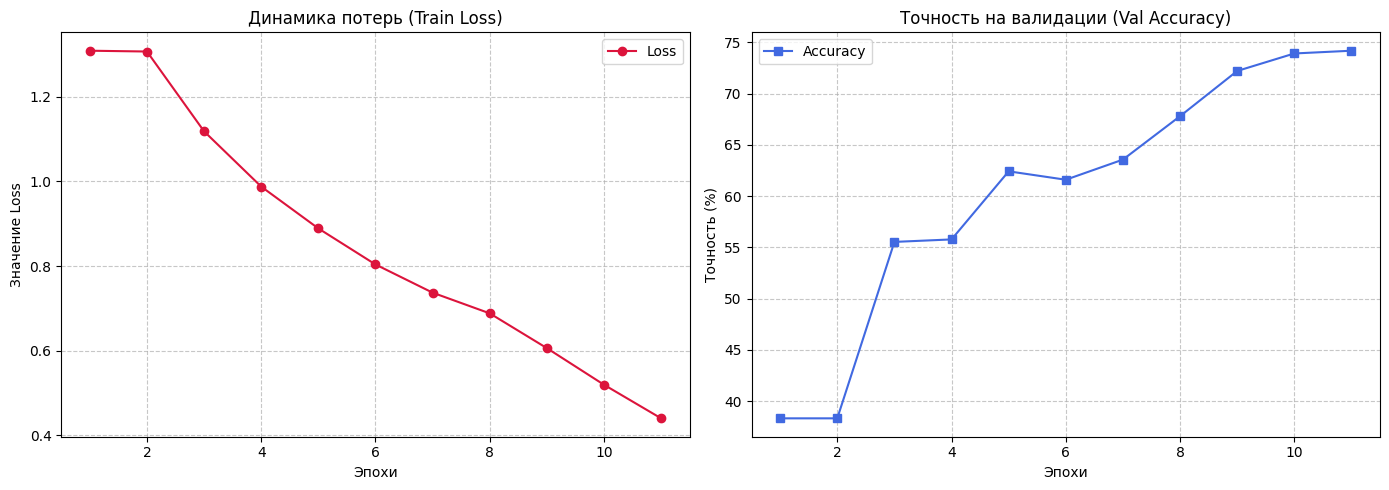

In [10]:
plot_training_results(history)

In [ ]:
def predict_comment(text, model, vocab, le, device):
    model.eval()
    
    tokens = tokenize(text)
    indices = [vocab.get(word, 1) for word in tokens] 
    
    input_tensor = torch.tensor([indices]).to(device)
    
    with torch.no_grad():
        output = model(input_tensor)
        predicted_idx = torch.argmax(output, dim=1).item()
    
    category = le.inverse_transform([predicted_idx])[0]
    
    probabilities = torch.softmax(output, dim=1)
    confidence = probabilities[0][predicted_idx].item() * 100
    
    return category, confidence

test_sentences = [
    "ENTER YOUR TEXT",
]

print("\n--- Результаты тестирования модели(result) ---")
for text in test_sentences:
    label, conf = predict_comment(text, model, vocab, le, device)
    print(f"Comment: {text}")
    print(f"Result: {label} ({conf:.2f}% confidence)\n")

In [ ]:
import os

def save_model_assets(model, vocab, le, history, folder='saved_model'):
    if not os.path.exists(folder):
        os.makedirs(folder)
    
    torch.save(model.state_dict(), f'{folder}/lstm_weights.pth')
    
    torch.save(model, f'{folder}/full_model.pt')
    
    with open(f'{folder}/vocab.pkl', 'wb') as f:
        pickle.dump(vocab, f)
    with open(f'{folder}/label_encoder.pkl', 'wb') as f:
        pickle.dump(le, f)
        
    with open(f'{folder}/history.pkl', 'wb') as f:
        pickle.dump(history, f)
        
    print(f"Все компоненты модели успешно сохранены в папку: {folder}")

save_model_assets(model, vocab, le, history)

Все компоненты модели успешно сохранены в папку: saved_model
